In [1]:
### to create neos but from neomod3 version of the plot using the new code

In [3]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [4]:
import sys
sys.path.insert(0, "../../src")
import matplotlib.pyplot as plt
import numpy as np
import NEOMOD3 as nm3
import NEOfaster as nf
import neoscore as nsc
import S3Marray as sm
import S3M_fullversion as smfull
import trojans as tjn
import neoonlyS3M as neo3m

In [5]:
df, array4D, H_center, a_center, e_center, i_center = nm3.getNEOMOD3orbits()

In [9]:
scorer = nsc.NEOMODScorer(array4D, H_center, a_center, e_center, i_center)

Starting computation...


Computing vlambda grid: 100%|██████████| 31/31 [1:40:27<00:00, 194.44s/it]

Computation complete!


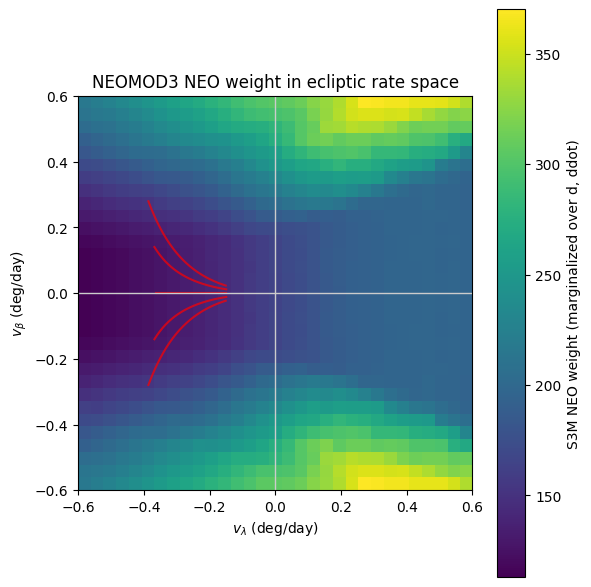

In [10]:
import sys
sys.path.insert(0, "../../src")
import numpy as np
import matplotlib.pyplot as plt
import neoscore as nsc
from tqdm import tqdm

# Observation params
obstime_str = "2025-09-23T00:00:00"
ra0_deg, dec0_deg = 0.0, 0.0
mag = 24.0

def comp_sum_with_scorer():
    """
    Compute marginalized weights over (vlambda, vbeta) grid using the scorer.
    """
    N_rate = 31
    vlam_min, vlam_max = -0.6, 0.6
    vbet_min, vbet_max = -0.6, 0.6
    vlam_vals = np.linspace(vlam_min, vlam_max, N_rate)
    vbet_vals = np.linspace(vbet_min, vbet_max, N_rate)
    
    K = np.zeros((len(vbet_vals), len(vlam_vals)), dtype=float)
    
    
    for i, vlam in enumerate(tqdm(vlam_vals, desc="Computing vlambda grid")):
        for j, vbet in enumerate(vbet_vals):
            # Convert ecliptic rates to RA/Dec rates
            dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
                ra0_deg, dec0_deg, vlam, vbet, obstime_str
            )
            
            # Use the scorer's marginalization method
            w_int = scorer.marginalize_over_distance(
                obstime_str=obstime_str,
                ra_deg=ra0_deg,
                dec_deg=dec0_deg,
                dra_deg_per_day=dra,
                ddec_deg_per_day=ddec,
                mag=mag
            )
            
            K[j, i] = w_int
    
    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent, vlam_vals, vbet_vals


print("Starting computation...")
K, extent, vlam_vals, vbet_vals = comp_sum_with_scorer()
print("Computation complete!")

# Prediction function 
vE_deg_per_day = 0.986  # Earth's orbital speed

def prediction_vlam_vbet(R_au, i_deg, phi_deg, beta_deg=0.0):
    """Predict ecliptic rates for given orbital parameters."""
    i = np.deg2rad(i_deg)
    phi = np.deg2rad(phi_deg)
    beta = np.deg2rad(beta_deg)
    
    theta = phi - np.arcsin(np.sin(phi) / R_au)
    Delta = np.sqrt(R_au**2 + 1.0 - 2.0 * R_au * np.cos(theta))
    
    v_factor = vE_deg_per_day / np.sqrt(R_au)
    vx = v_factor * np.cos(i) * np.sin(theta)
    vy = v_factor * np.cos(i) * np.cos(theta)
    vz = v_factor * np.sin(i)
    
    vlam = (np.sin(phi) * vx + np.cos(phi) * (vy - vE_deg_per_day)) / Delta
    vbet = (-np.sin(beta) * np.cos(phi) * vx
            + np.sin(beta) * np.sin(phi) * (vy - vE_deg_per_day)
            + np.cos(beta) * vz) / Delta
    
    return vlam, vbet

# Generate prediction curves for different inclinations
phi_deg = 0.0  # opposition
beta_deg = 0.0  # on the ecliptic
i_list = np.arange(-10.0, 15.0, 5.0)  # -10, -5, 0, 5, 10
R_vals = np.linspace(1.5, 4.5, 800)  # AU

i_lines = []
for i_deg in i_list:
    vlam_arr = []
    vbet_arr = []
    for R in R_vals:
        vlam, vbet = prediction_vlam_vbet(R, i_deg, phi_deg, beta_deg)
        vlam_arr.append(vlam)
        vbet_arr.append(vbet)
    i_lines.append((np.array(vlam_arr), np.array(vbet_arr), i_deg))


plt.figure(figsize=(6.0, 6.0))
im = plt.imshow(K, origin="lower", extent=extent, cmap="viridis", aspect="equal")
plt.colorbar(label="S3M NEO weight (marginalized over d, ddot)")

# Plot prediction curves
for vlam_arr, vbet_arr, i_deg in i_lines:
    plt.plot(vlam_arr, vbet_arr, 'r-', lw=1.5, alpha=0.7, 
             label=f'i={i_deg}°' if i_deg == i_list[0] else '')

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.xlim(-0.6, 0.6)
plt.ylim(-0.6, 0.6)
plt.title("NEOMOD3 NEO weight in ecliptic rate space")
plt.tight_layout()
plt.show()